In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import kagglehub  # pip install kagglehub

## Load Data

In [30]:
SAMPLE_SIZE = 50000 # some of the data sets are large 


def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if (sample_size and row_count > sample_size) and sample_size > 0:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

In [ ]:
# Load Data using default sample 
# instacart is 3Million records so we are just going to use about 50K
#df = load_csv_sampled("../data_instacart_combined.csv")

# df = load_csv_sampled("../2019-Nov.csv", sample_size=-1)
# split = df['category_code'].dropna().str.split('.')
# df[['department', 'category', 'subcategory']] = df['category_code'].str.split('.', n=2, expand=True)
# # df['department'] = split.str[0]
# # df['category'] = split.str[1]
# # df['subcategory'] = split.str[2]

Loaded 67,501,979 rows [encoding: utf-8]


In [41]:
df_full = df

In [ ]:
# df_sample = df.sample(100000, random_state=42)


df_sample = load_csv_sampled("../2019-Nov-enriched.csv", sample_size=100000)

Loaded 100,000 rows (sampled from 67,501,979) [encoding: utf-8]


In [42]:
df = df_sample



## Preprocessing

In [43]:
def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


print("summarize sample")
summarize_df(df)

summarize sample
Shape: 100,000 x 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67659 non-null   object 
 5   brand          86426 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
 9   department     67659 non-null   object 
 10  category       67659 non-null   object 
 11  subcategory    27892 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 9.2+ MB

Numeric


,count,mean,std,min,25%,50%,75%,max
product_id,100000.0,1.244612e+07,1.721327e+07,1.000978e+06,1.304409e+06,5.100564e+06,1.730035e+07,1.000283e+08
category_id,100000.0,2.057846e+18,2.000412e+16,2.053014e+18,2.053014e+18,2.053014e+18,2.053014e+18,2.187708e+18
price,100000.0,2.938553e+02,3.559636e+02,0.000000e+00,6.947000e+01,1.668200e+02,3.660100e+02,2.574070e+03
user_id,100000.0,5.386151e+08,2.290210e+07,8.097079e+07,5.164595e+08,5.350157e+08,5.610442e+08,5.799630e+08


Categorical


,count,unique,top,freq
event_time,100000,96603,2019-11-17 12:24:03 UTC,4
event_type,100000,3,view,94125
category_code,67659,123,electronics.smartphone,24421
brand,86426,2189,samsung,11685
user_session,100000,98857,d99d91bf-40f8-4e29-9593-54b4a1826542,9
department,67659,13,electronics,35653
category,67659,56,smartphone,24421
subcategory,27892,81,tv,3227


In [44]:
def check_dup_rows(df):
    dups = df.duplicated().sum()
    print(f"Duplicate rows: {dups:,} ({dups/len(df)*100:.2f}%)")
    if dups > 0:
        display(df[df.duplicated(keep=False)].head(10))
    return dups



print("duplicate row checks")
check_dup_rows(df)

print("\n")


duplicate row checks
Duplicate rows: 1 (0.00%)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,department,category,subcategory
33682,2019-11-13 15:58:18 UTC,cart,1801940,2053013554415534427,electronics.video.tv,haier,231.64,571077412,d087958c-888c-4398-8648-0679afc493be,electronics,video,tv
33683,2019-11-13 15:58:18 UTC,cart,1801940,2053013554415534427,electronics.video.tv,haier,231.64,571077412,d087958c-888c-4398-8648-0679afc493be,electronics,video,tv


duplicate column checks 


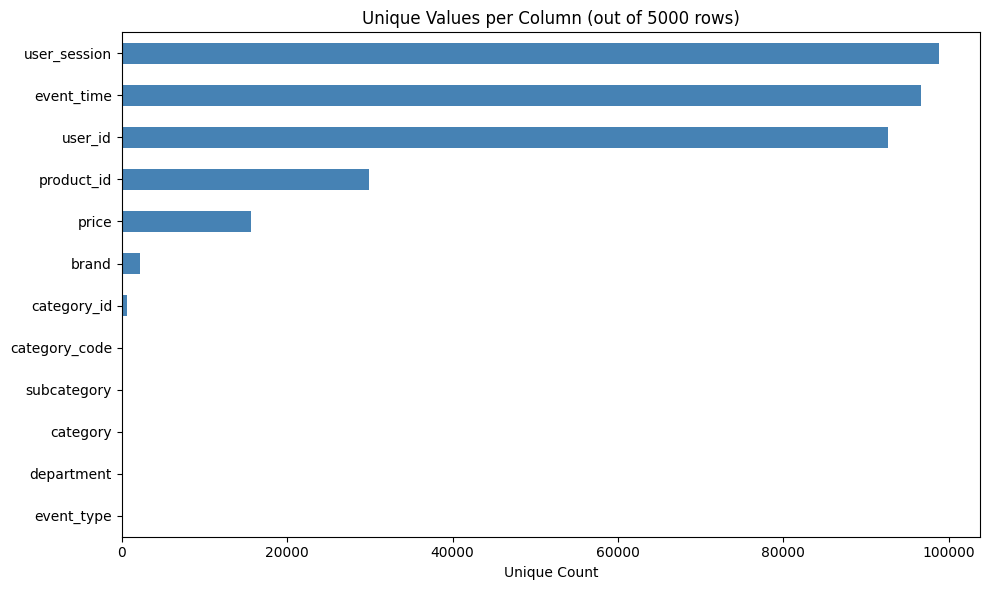

               Unique Count  Total Row Count
event_type                3           100000
department               13           100000
category                 56           100000
subcategory              81           100000
category_code           123           100000
category_id             616           100000
brand                  2189           100000
price                 15570           100000
product_id            29926           100000
user_id               92710           100000
event_time            96603           100000
user_session          98857           100000


In [45]:
import matplotlib.pyplot as plt
def check_dup_values(df):
    unique_counts = df.nunique()
    # Get the total row count
    total_rows = df.shape[0]

    # Create a new DataFrame with the results
    summary_df = pd.DataFrame({
        'Unique Count': unique_counts,
        'Total Row Count': total_rows
    })

    # Display the summary DataFrame
    summary_df.sort_values('Unique Count', inplace=True)
    summary_df['Unique Count'].plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.xlabel('Unique Count')
    plt.title('Unique Values per Column (out of 5000 rows)')
    plt.tight_layout()
    plt.show()
    print(summary_df)

print("duplicate column checks ")
check_dup_values(df)


## Univariate Analysis

In [46]:
## helpers
import matplotlib.pyplot as plt
import seaborn as sns


def plot_histogram(df, feature, ax, bins=30):
    data = df[feature].dropna()
    _= ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set(title=f'Histogram — {feature}', xlabel=feature, ylabel='Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=8)
    return ax

def plot_kde(df, feature, ax):
    data = df[feature].dropna()
    sns.kdeplot(data, ax=ax, fill=True, color='teal', alpha=0.4, linewidth=2)
    ax.set(title=f'KDE — {feature}', xlabel=feature, ylabel='Density')
    return ax

def plot_swarm(df, feature, ax, sample_n=200):
    data = df[feature].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    _ = sns.swarmplot(y=data, ax=ax, color='coral', size=2.5, alpha=0.7)
    ax.set(title=f'Swarm — {feature} (n={len(data)})', ylabel=feature)
    return ax

def plot_violin(df, feature, ax):
    _ =  sns.violinplot(y=df[feature].dropna(), ax=ax, color='mediumpurple',
                   inner='box', linewidth=1.2)
    ax.set(title=f'Violin — {feature}', ylabel=feature)
    return ax

def plot_categorical_bar_chart(df, feature, ax):
    df[feature].value_counts().head(20).plot(kind='bar', ax=ax, color='goldenrod', edgecolor='white')
    ax.set(title=f'Value Counts — {feature}', xlabel=feature, ylabel='Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

def plot_bin_sensitivity(df, feature):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, bins in zip(axes, [5, 15, 30, 100]):
        ax.hist(df[feature].dropna(), bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
        ax.set(title=f'{bins} bins', xlabel=feature, ylabel='Count')
    plt.suptitle(f'Bin Sensitivity — {feature}')
    plt.tight_layout()
    plt.show()

def plot_numeric_univariate(df, feature): #Univariate Numeric -> histogram + kde + violin + swarm
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plot_histogram(df, feature, ax=axes[0])
    plot_kde(df, feature, ax=axes[1])
    plot_swarm(df, feature, ax=axes[2])
    plot_violin(df, feature, ax=axes[3])
    plt.tight_layout()
    plt.show()

    plot_bin_sensitivity(df, feature)  # <-- add this
    
def plot_categorical_univariate(df, feature): #Univariate Categorical       # value counts bar
     fig, ax = plt.subplots(figsize=(12, 4))
     plot_categorical_bar_chart(df, feature, ax)



def plot_grouped_multi_variate(df, groupings):
    fig, axes = plt.subplots(1, len(groupings), figsize=(6 * len(groupings), 4))
    if len(groupings) == 1:
        axes = [axes]
    for ax, (feature, group_by) in zip(axes, groupings):
        for group in df[group_by].unique():
            data = df[df[group_by] == group][feature].dropna()
            sns.kdeplot(data, ax=ax, fill=True, alpha=0.3, label=group, linewidth=2)
        ax.set(title=f'{feature} by {group_by}', xlabel=feature, ylabel='Density')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [21]:
skip_patterns = ['_id', ' id', 'row', 'postal', 'city', 'state', 'name', 'date', 'number', '_code'] ## skip columns that are not good for charting 
def analyze_dataset(df, groups, dataset_name='Dataset'):

    print(f"{'='*100}")
    print(f"  {dataset_name}")
    print(f"{'='*100}")

    summarize_df(df)
    
    print("\n--- Numeric Features ---")
    for col in df.select_dtypes(include='number').columns:
        if not any(p in col.lower() for p in skip_patterns):
            plot_numeric_univariate(df, col)

    print("\n--- Categorical Features ---")
    for col in df.select_dtypes(include=['object', 'category']).columns:
      if not any(p in col.lower() for p in skip_patterns):
        plot_categorical_univariate(df, col)

    print("\n--- Grouped Features ---")
    plot_grouped_multi_variate(df,groups)

  Us Ecomm Records
Shape: 100,000 x 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67659 non-null   object 
 5   brand          86426 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
 9   department     67659 non-null   object 
 10  category       67659 non-null   object 
 11  subcategory    27892 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 9.2+ MB

Numeric


,count,mean,std,min,25%,50%,75%,max
product_id,100000.0,1.244612e+07,1.721327e+07,1.000978e+06,1.304409e+06,5.100564e+06,1.730035e+07,1.000283e+08
category_id,100000.0,2.057846e+18,2.000412e+16,2.053014e+18,2.053014e+18,2.053014e+18,2.053014e+18,2.187708e+18
price,100000.0,2.938553e+02,3.559636e+02,0.000000e+00,6.947000e+01,1.668200e+02,3.660100e+02,2.574070e+03
user_id,100000.0,5.386151e+08,2.290210e+07,8.097079e+07,5.164595e+08,5.350157e+08,5.610442e+08,5.799630e+08


Categorical


,count,unique,top,freq
event_time,100000,96603,2019-11-17 12:24:03 UTC,4
event_type,100000,3,view,94125
category_code,67659,123,electronics.smartphone,24421
brand,86426,2189,samsung,11685
user_session,100000,98857,d99d91bf-40f8-4e29-9593-54b4a1826542,9
department,67659,13,electronics,35653
category,67659,56,smartphone,24421
subcategory,27892,81,tv,3227



--- Numeric Features ---


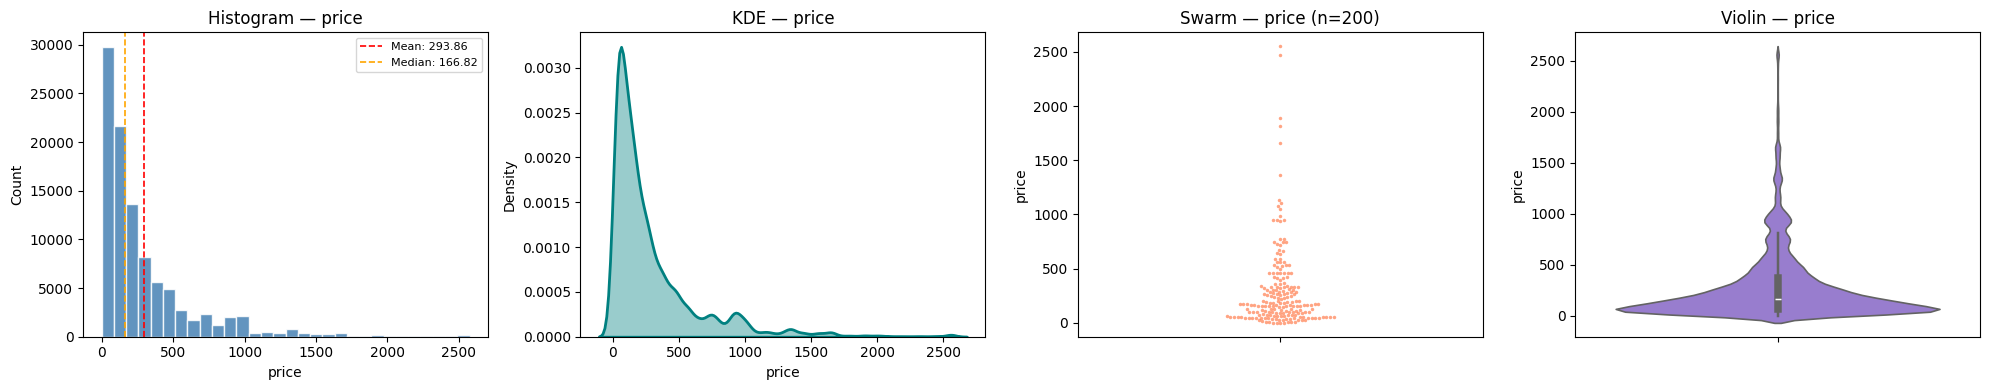

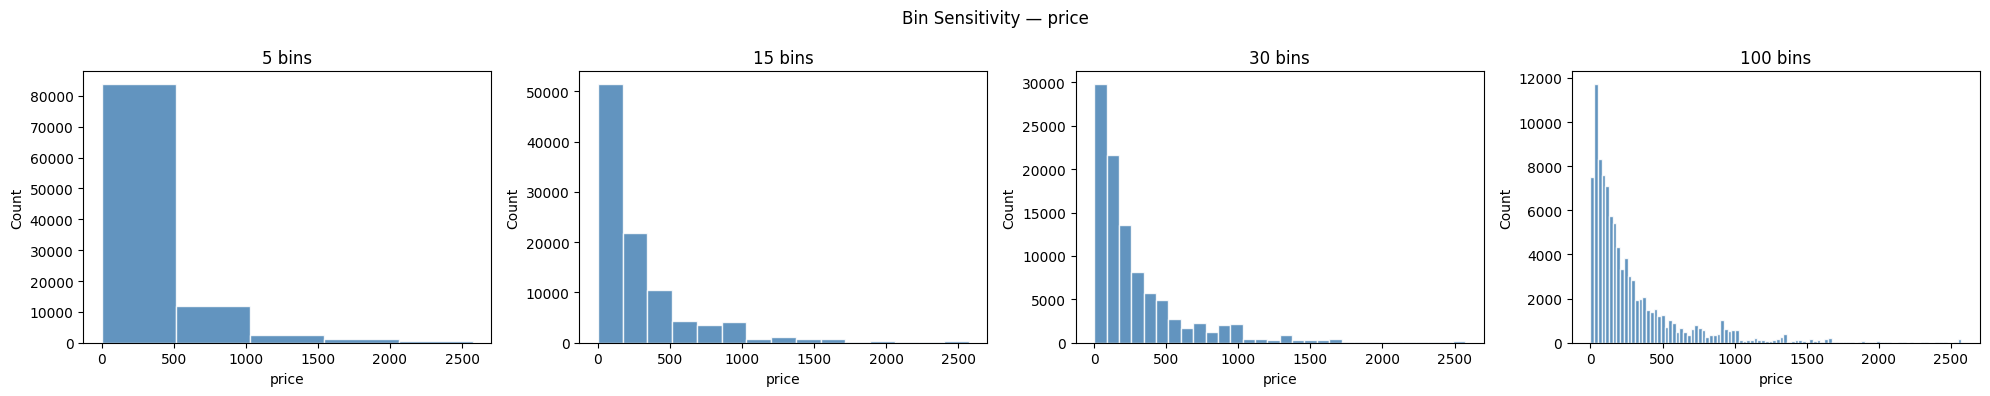


--- Categorical Features ---


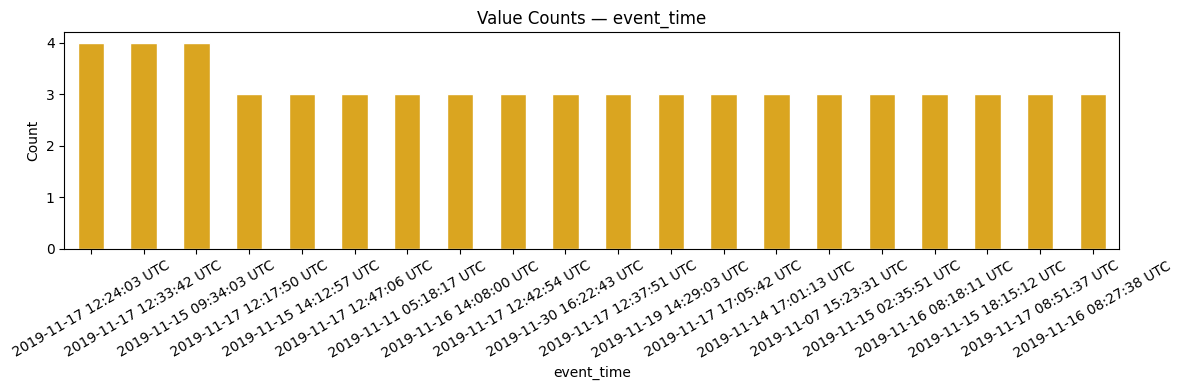

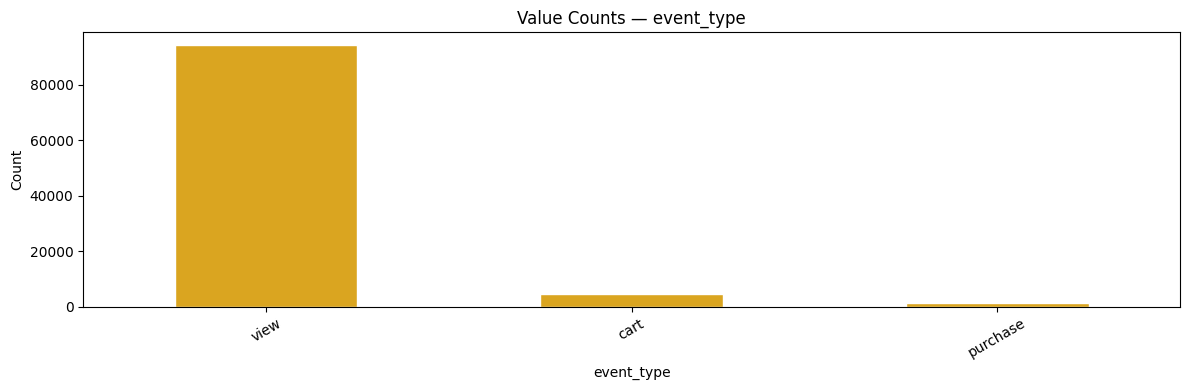

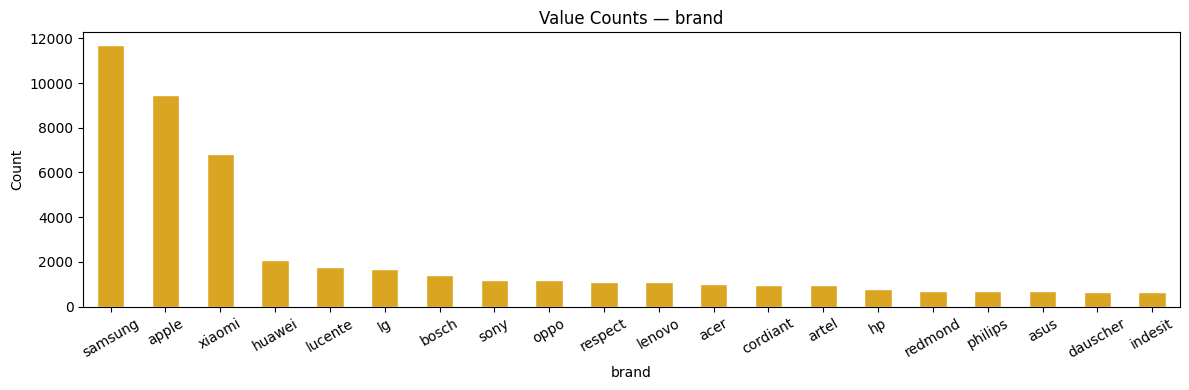

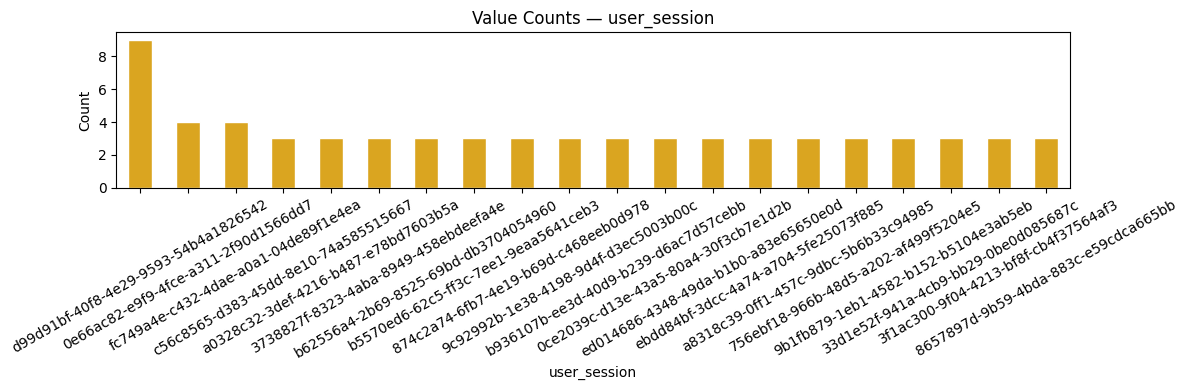

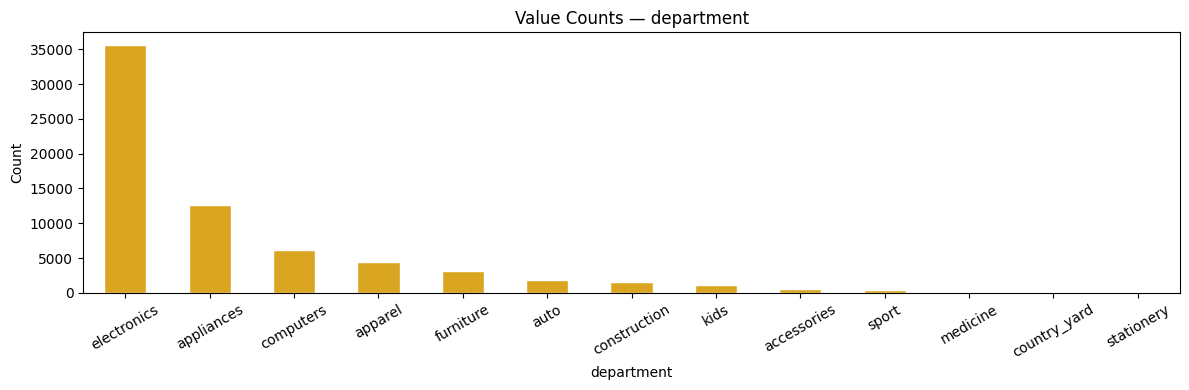

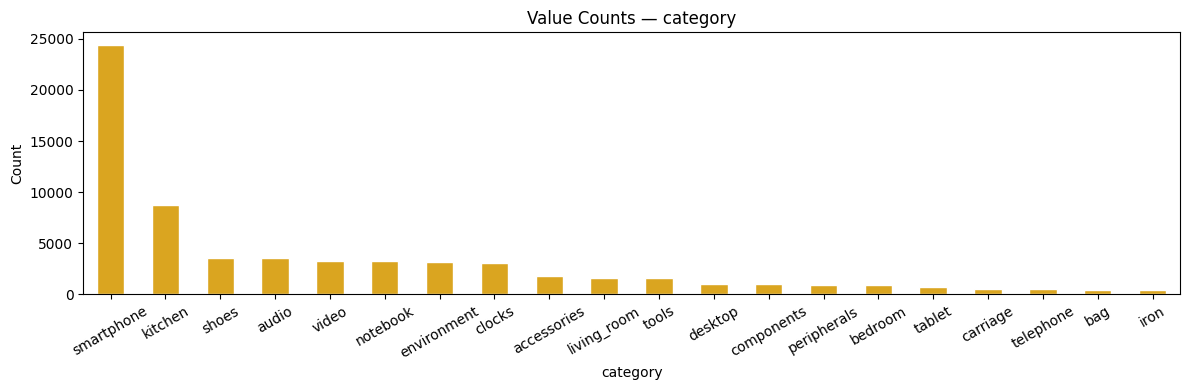

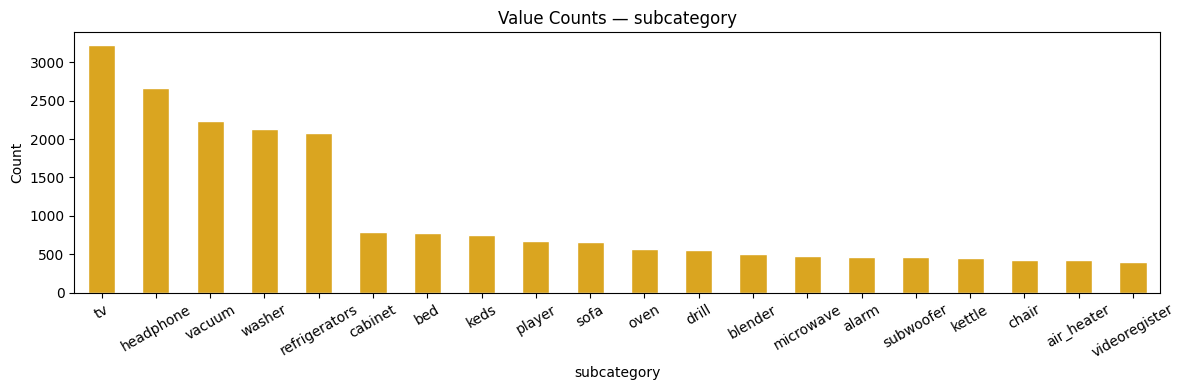


--- Grouped Features ---


/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93514/614216067.py:75: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, ax=ax, fill=True, alpha=0.3, label=group, linewidth=2)
/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93514/614216067.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


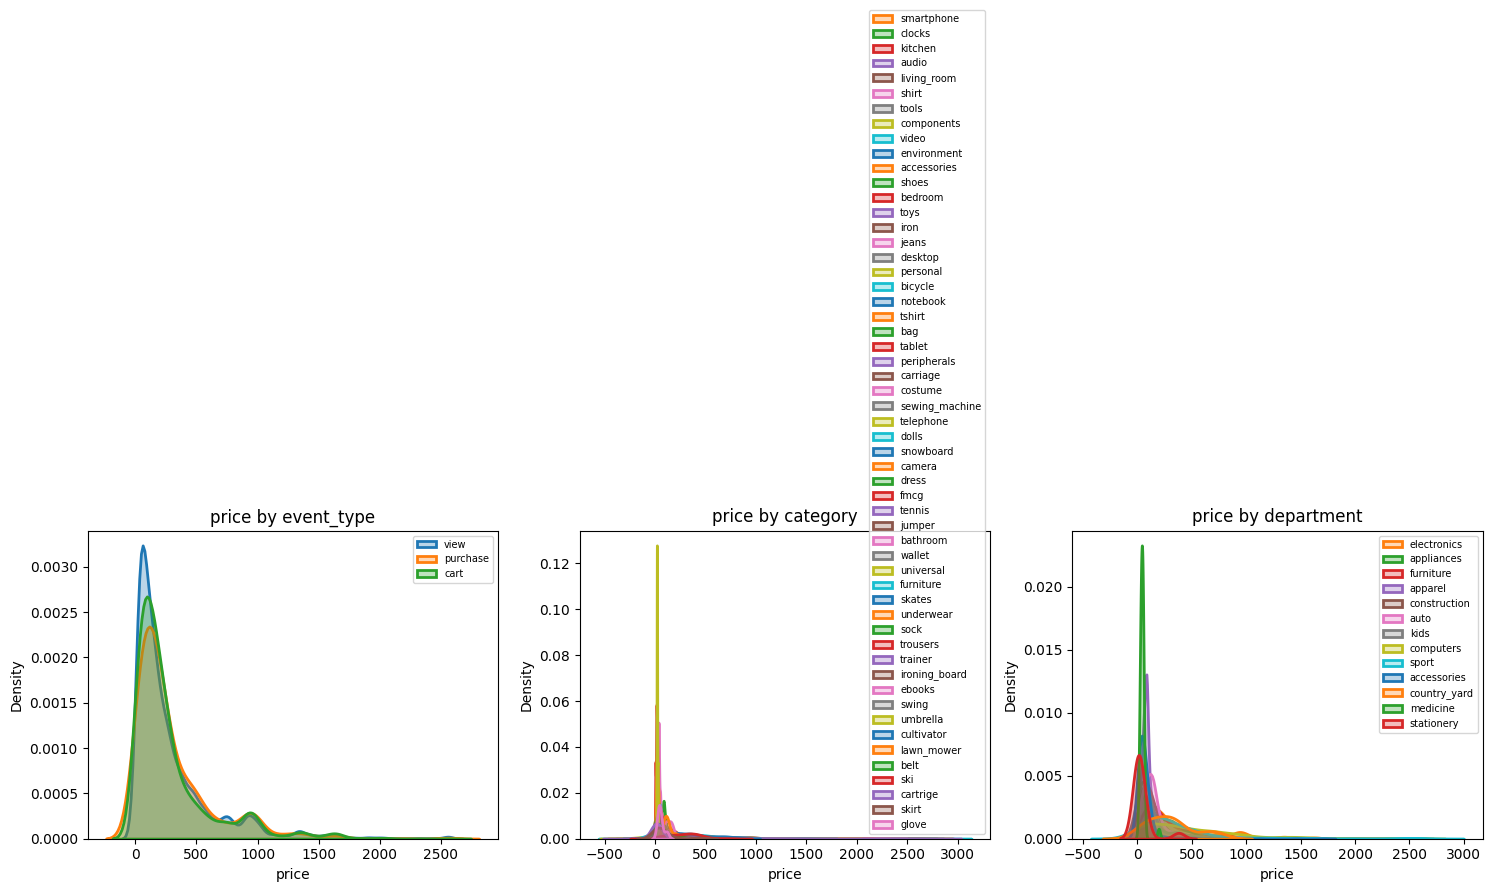

In [47]:

groupings = [
    ('price', 'event_type'),
    ('price', 'category'),
    ('price', 'department'),
]
analyze_dataset(df,groupings, dataset_name='Us Ecomm Records')

## Bivariate Analysis

In [10]:
## Bivariate helpers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pairplot(df, numeric_cols, hue_col=None, sample_n=1000):
    data = df[numeric_cols + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    g = sns.pairplot(data, hue=hue_col, plot_kws={'alpha': 0.3, 's': 15},
                     diag_kind='kde', palette='tab10')
    g.fig.suptitle('Pairplot' + (f' by {hue_col}' if hue_col else ''), y=1.02)
    plt.show()


def plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=None, agg='mean'):
    if groupby_col:
        for group, gdf in df.groupby(groupby_col):
            agg_data = gdf.groupby(time_col)[numeric_col].agg(agg).sort_index()
            ax.plot(agg_data.index, agg_data.values, label=str(group), alpha=0.8)
        ax.legend(fontsize=7, title=groupby_col)
    else:
        agg_data = df.groupby(time_col)[numeric_col].agg(agg).sort_index()
        ax.fill_between(agg_data.index, agg_data.values, alpha=0.3, color='steelblue')
        ax.plot(agg_data.index, agg_data.values, color='steelblue', linewidth=2)
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {time_col}')
    ax.set_xlabel(time_col)
    ax.set_ylabel(f'{agg} {numeric_col}')


def plot_correlation_heatmap(df, numeric_cols, ax):
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_boxplot_by_category(df, numeric_col, cat_col, ax, top_n=10):
    top_cats = df[cat_col].value_counts().head(top_n).index
    data = df[df[cat_col].isin(top_cats)]
    sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,
                palette='Set2', order=top_cats)
    ax.set_title(f'{numeric_col} by {cat_col} (top {top_n})')
    ax.tick_params(axis='x', rotation=40)


def plot_grouped_bar(df, cat_col, numeric_col, ax, top_n=10, agg='mean'):
    grouped = df.groupby(cat_col)[numeric_col].agg(agg).sort_values(ascending=False).head(top_n)
    grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {cat_col} (top {top_n})')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f'{agg} {numeric_col}')
    ax.tick_params(axis='x', rotation=40)


def plot_heatmap_two_categoricals(df, col_x, col_y, ax, top_n=10):
    top_x = df[col_x].value_counts().head(top_n).index
    top_y = df[col_y].value_counts().head(top_n).index
    pivot = df[df[col_x].isin(top_x) & df[col_y].isin(top_y)]\
              .groupby([col_y, col_x]).size().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Count Heatmap: {col_y} vs {col_x}')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_scatter(df, col_x, col_y, ax, sample_n=2000, hue_col=None):
    data = df[[col_x, col_y] + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    sns.scatterplot(data=data, x=col_x, y=col_y, ax=ax,
                    hue=hue_col, alpha=0.4, s=20,
                    palette='tab10' if hue_col else None)
    ax.set_title(f'{col_x} vs {col_y}' + (f' (by {hue_col})' if hue_col else ''))


def analyze_dataset_bi_variate(
    df,
    numeric_cols,            # list of numeric cols for correlation heatmap
    boxplot_pairs,           # list of (numeric_col, cat_col)
    grouped_bar_pairs,       # list of (cat_col, numeric_col, agg) — agg: 'mean' | 'sum' | 'median'
    heatmap_pairs,           # list of (col_x, col_y) — two categoricals
    scatter_pairs,           # list of (col_x, col_y) or (col_x, col_y, hue_col)
    pairplot_cols=None,      # (numeric_cols_list, optional hue_col)
    line_pairs=None,          # list of (time_col, numeric_col, agg) or (time_col, numeric_col, agg, groupby_col)
    dataset_name='Dataset'
):
    print(f"{'='*100}")
    print(f"  {dataset_name} — Bivariate Analysis")
    print(f"{'='*100}")

    # Correlation heatmap
    if numeric_cols:
        print("\n--- Correlation Matrix ---")
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_correlation_heatmap(df, numeric_cols, ax)
        plt.tight_layout()
        plt.show()

    # Boxplots
    if boxplot_pairs:
        print("\n--- Boxplots ---")
        for numeric_col, cat_col in boxplot_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_boxplot_by_category(df, numeric_col, cat_col, ax)
            plt.tight_layout()
            plt.show()

    # Grouped bar charts
    if grouped_bar_pairs:
        print("\n--- Grouped Bar Charts ---")
        for cat_col, numeric_col, agg in grouped_bar_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_grouped_bar(df, cat_col, numeric_col, ax, agg=agg)
            plt.tight_layout()
            plt.show()

    # Two-categorical heatmaps
    if heatmap_pairs:
        print("\n--- Category Heatmaps ---")
        for col_x, col_y in heatmap_pairs:
            fig, ax = plt.subplots(figsize=(12, 6))
            plot_heatmap_two_categoricals(df, col_x, col_y, ax)
            plt.tight_layout()
            plt.show()

    # Scatter plots
    if scatter_pairs:
        print("\n--- Scatter Plots ---")
        for pair in scatter_pairs:
            col_x, col_y = pair[0], pair[1]
            hue_col = pair[2] if len(pair) == 3 else None
            fig, ax = plt.subplots(figsize=(10, 6))
            plot_scatter(df, col_x, col_y, ax, hue_col=hue_col)
            plt.tight_layout()
            plt.show()
    # Pairplot
    if pairplot_cols:
        print("\n--- Pairplot ---")
        cols, hue_col = pairplot_cols[0], pairplot_cols[1] if len(pairplot_cols) > 1 else None
        plot_pairplot(df, cols, hue_col=hue_col)

    # Line / area graphs
    if line_pairs:
        print("\n--- Line / Area Graphs ---")
        for pair in line_pairs:
            time_col, numeric_col, agg = pair[0], pair[1], pair[2]
            groupby_col = pair[3] if len(pair) == 4 else None
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=groupby_col, agg=agg)
            plt.tight_layout()
            plt.show()

  eCommerce Behavior — Bivariate Analysis

--- Correlation Matrix ---


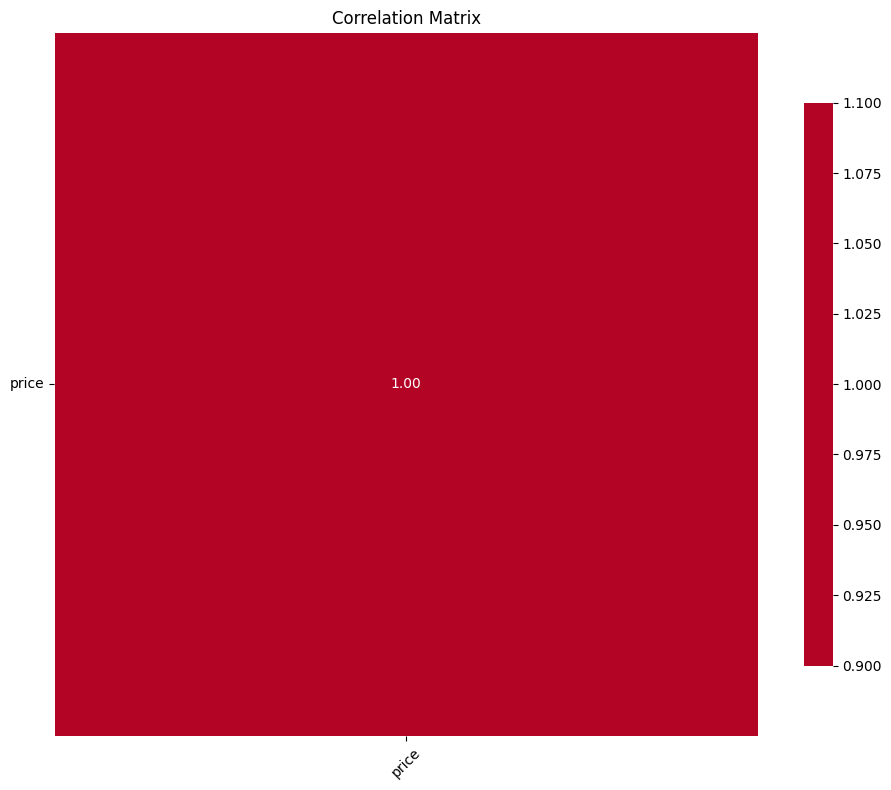


--- Boxplots ---


/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93514/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


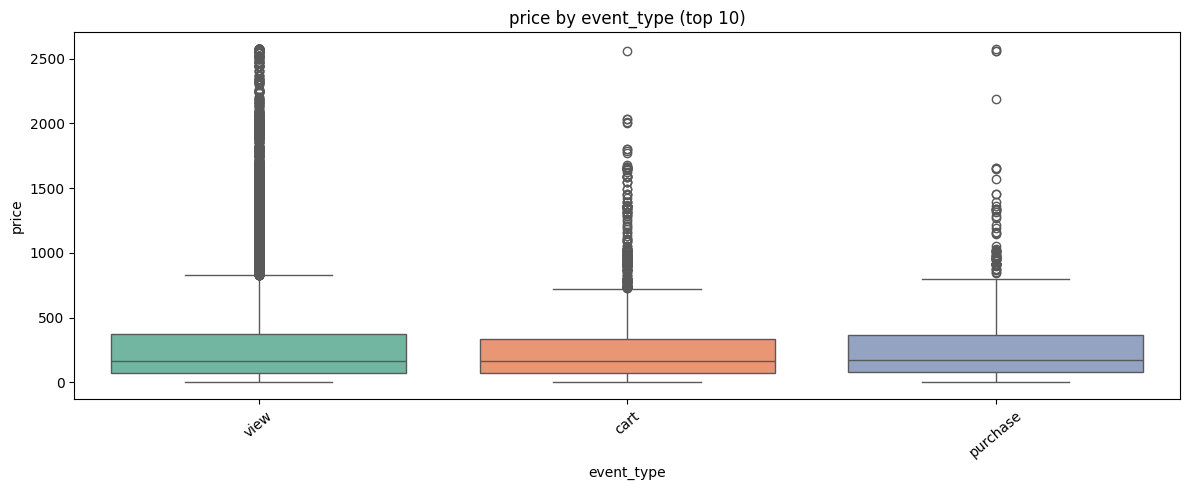

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93514/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


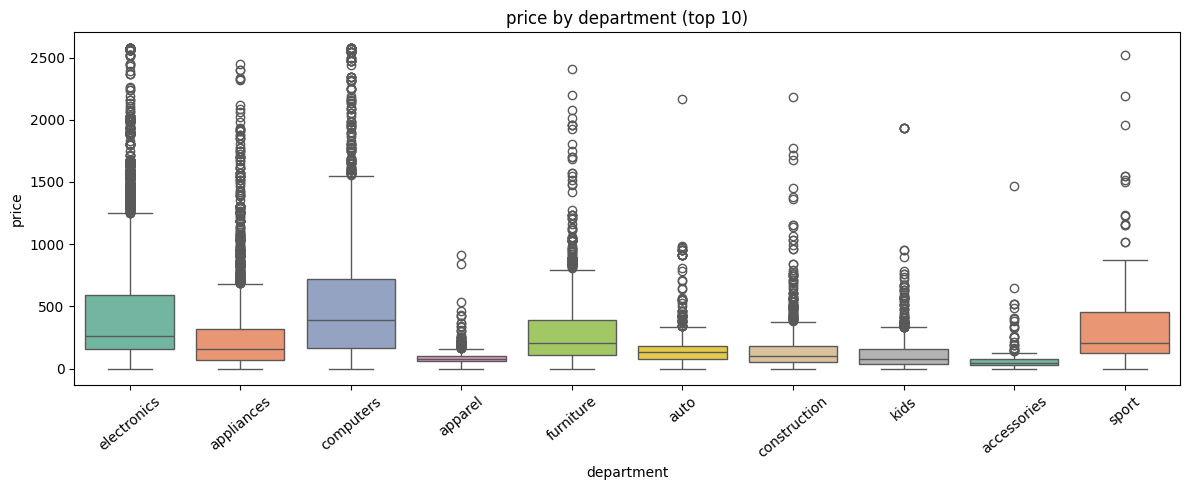


--- Grouped Bar Charts ---


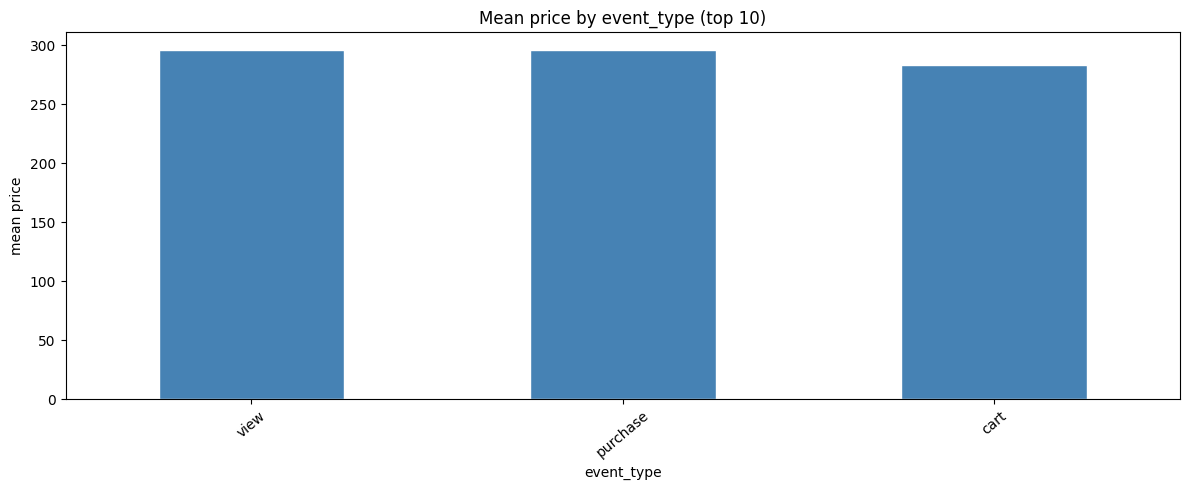

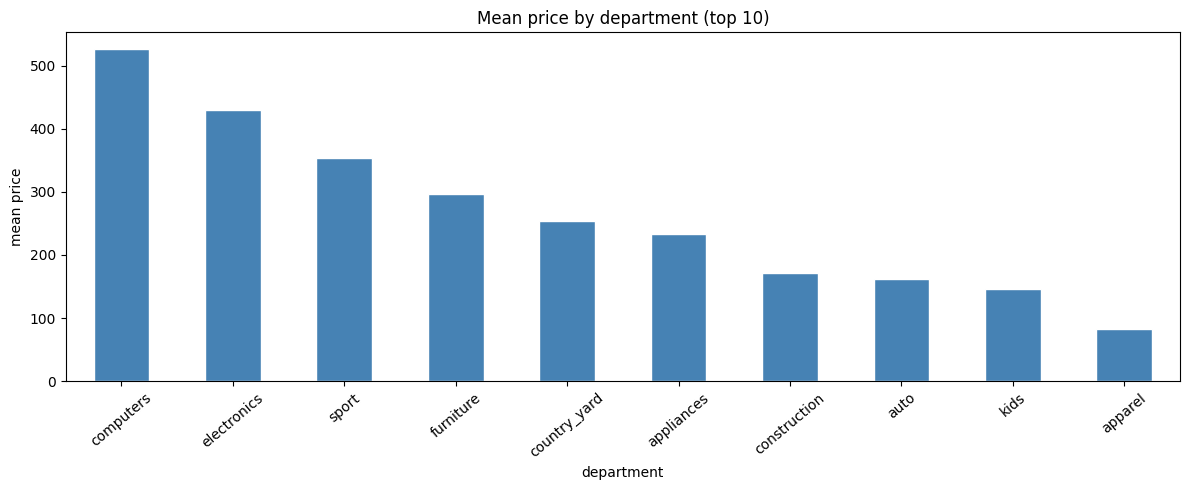


--- Category Heatmaps ---


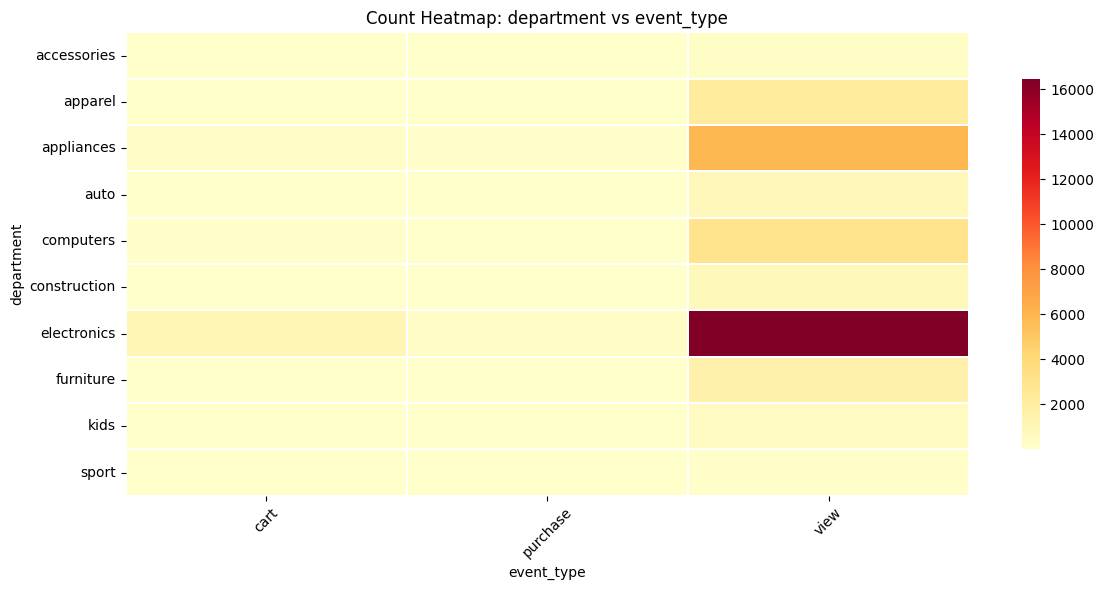


--- Line / Area Graphs ---


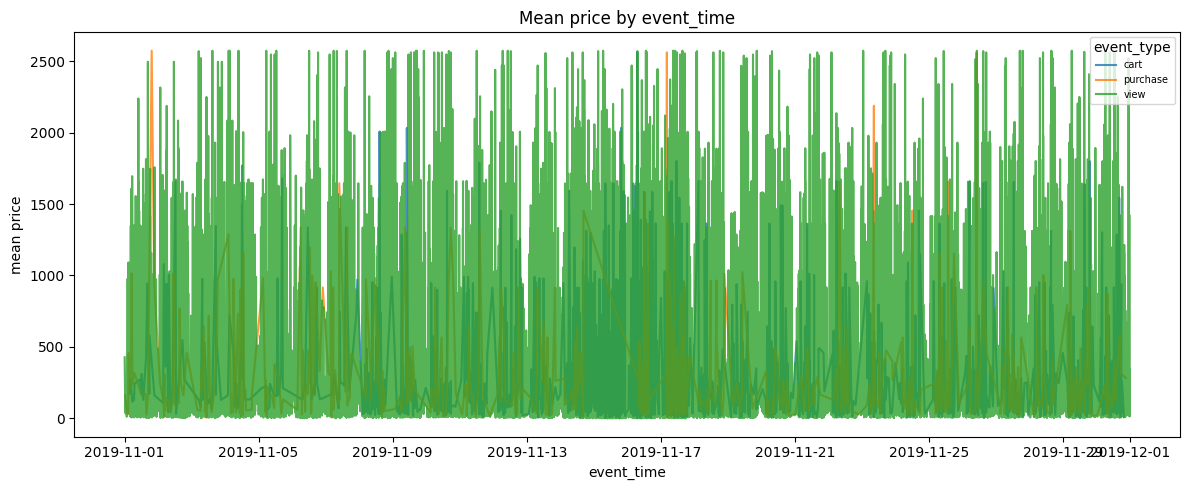

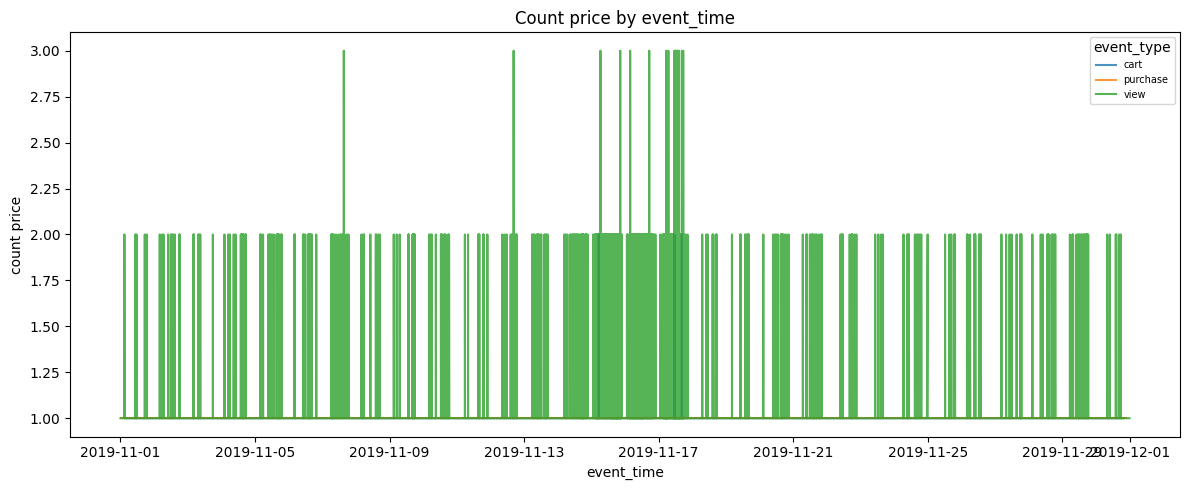

In [24]:
# E-Commerce Behavior bivariate analysis
# E-Commerce Behavior bivariate analysis
df['event_time'] = pd.to_datetime(df['event_time'])

# Parse category hierarchy
split = df['category_code'].dropna().str.split('.')
df['department'] = split.str[0]
df['category'] = split.str[1]
df['subcategory'] = split.str[2]

numeric_cols = ['price']

# (numeric_col, cat_col)
boxplot_pairs = [
    ('price', 'event_type'),
    ('price', 'department'),
]

# (cat_col, numeric_col, agg)
grouped_bar_pairs = [
    ('event_type', 'price', 'mean'),
    ('department', 'price', 'mean'),
]

# (col_x, col_y) — two categoricals
heatmap_pairs = [
    ('event_type', 'department'),  # was category_code, now department — manageable cardinality
]

# skip — only one numeric col
scatter_pairs = []
pairplot_cols = None

line_pairs = [
    ('event_time', 'price', 'mean', 'event_type'),
    ('event_time', 'price', 'count', 'event_type'),
]

analyze_dataset_bi_variate(
    df,
    numeric_cols=numeric_cols,
    boxplot_pairs=boxplot_pairs,
    grouped_bar_pairs=grouped_bar_pairs,
    heatmap_pairs=heatmap_pairs,
    scatter_pairs=scatter_pairs,
    pairplot_cols=pairplot_cols,
    line_pairs=line_pairs,
    dataset_name='eCommerce Behavior'
)

## Figures Export

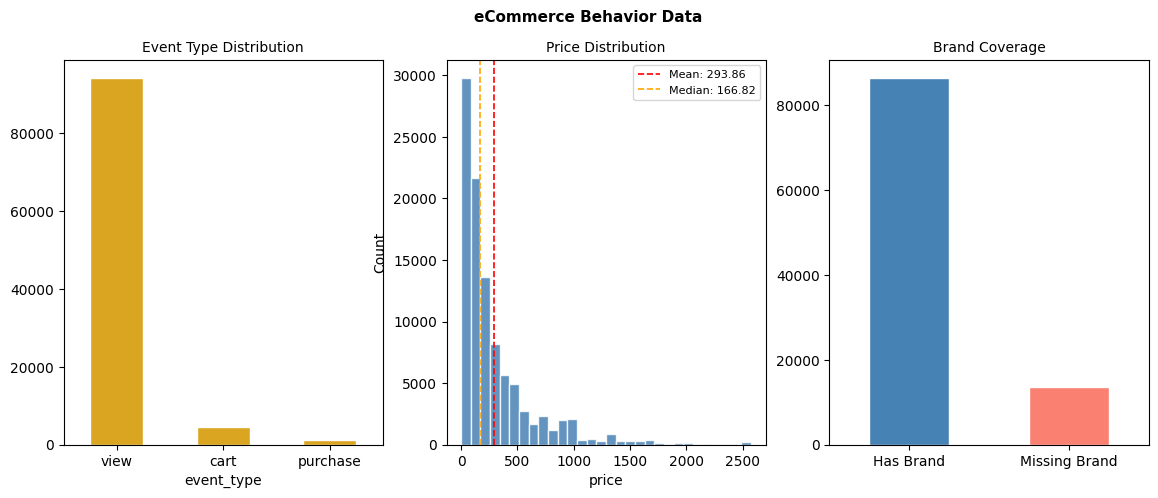

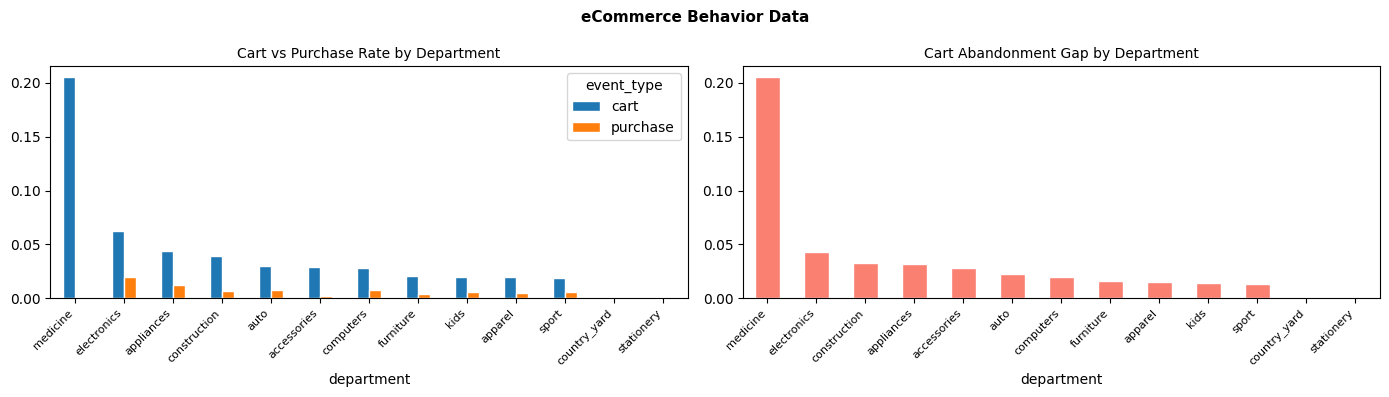

<Figure size 640x480 with 0 Axes>

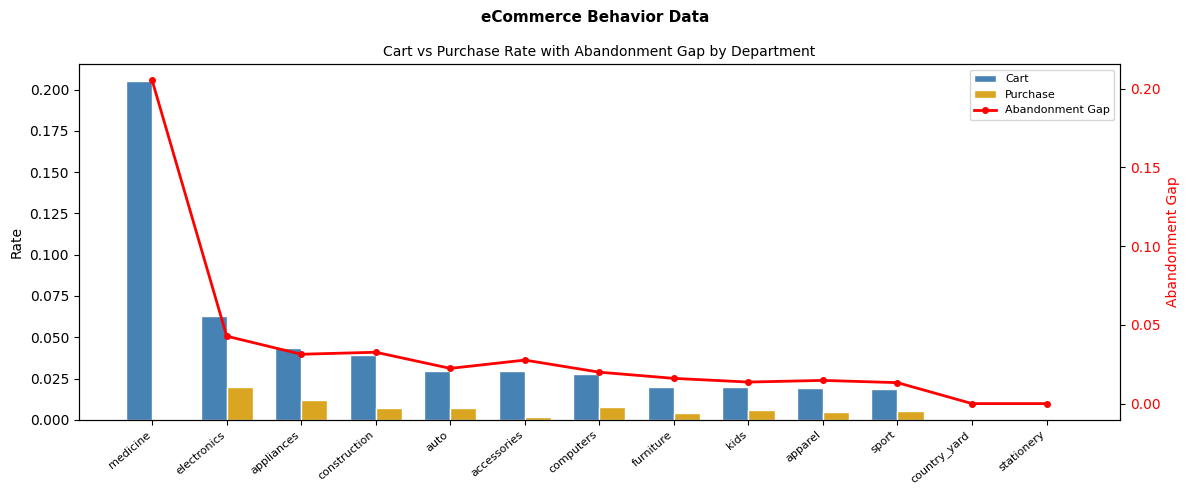

In [56]:
import os
os.makedirs('figures', exist_ok=True)

os.makedirs('figures', exist_ok=True)
fig_size = (6, 5)

DATASET_TITLE = "eCommerce Behavior Data"


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Left — Event type counts
df['event_type'].value_counts().plot(kind='bar', ax=axes[0], color='goldenrod', edgecolor='white')
axes[0].set_title('Event Type Distribution', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)

# Middle — Price distribution
plot_histogram(df, 'price', axes[1])
axes[1].set_title('Price Distribution', fontsize=10)

# Right — Brand coverage (non-null vs null)
brand_coverage = df['brand'].isna().value_counts()
brand_coverage.index = ['Has Brand', 'Missing Brand']
brand_coverage.plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon'], edgecolor='white')
axes[2].set_title('Brand Coverage', fontsize=10)
axes[2].tick_params(axis='x', rotation=0)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')


def clean_labels(ax, rotation=45, ha='right', fontsize=8):
    ax.tick_params(axis='x', rotation=rotation)
    ax.set_xticklabels(ax.get_xticklabels(), ha=ha, fontsize=fontsize)
    plt.tight_layout()

# Left — Cart vs Purchase rate by department
conversion = df[df['department'].notna()].groupby('department')['event_type']\
    .value_counts(normalize=True).unstack().fillna(0)
conversion[['cart', 'purchase']].sort_values('cart', ascending=False)\
    .plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Cart vs Purchase Rate by Department', fontsize=10)
clean_labels(axes[0])

# Right — Cart abandonment gap
conversion['abandonment'] = conversion['cart'] - conversion['purchase']
conversion['abandonment'].sort_values(ascending=False)\
    .plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Cart Abandonment Gap by Department', fontsize=10)
clean_labels(axes[1])

plt.tight_layout()
plt.savefig('figures/fig6_behavior_bivariate.png', dpi=150)
plt.show()

plt.tight_layout()
plt.savefig('figures/fig3_behavior_univariate.png', dpi=150)
plt.show()


fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Grouped bars — cart vs purchase
conversion = df[df['department'].notna()].groupby('department')['event_type']\
    .value_counts(normalize=True).unstack().fillna(0)
conversion['abandonment'] = conversion['cart'] - conversion['purchase']
conversion = conversion.sort_values('cart', ascending=False)

x = range(len(conversion))
width = 0.35
ax1.bar([i - width/2 for i in x], conversion['cart'], width, label='Cart', color='steelblue', edgecolor='white')
ax1.bar([i + width/2 for i in x], conversion['purchase'], width, label='Purchase', color='goldenrod', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(conversion.index, rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('Rate')
ax1.set_title('Cart vs Purchase Rate with Abandonment Gap by Department', fontsize=10)

# Line overlay — abandonment gap
ax2 = ax1.twinx()
ax2.plot(list(x), conversion['abandonment'], color='red', linewidth=2, marker='o', markersize=4, label='Abandonment Gap')
ax2.set_ylabel('Abandonment Gap', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig6_behavior_bivariate.png', dpi=150)
plt.show()



In [31]:

df_full = load_csv_sampled("../2019-Nov.csv", sample_size=-1)

Loaded 67,501,979 rows [encoding: utf-8]


In [29]:
print("Sample distribution:")
print(df['event_type'].value_counts())
print(df['event_type'].value_counts(normalize=True))

Sample distribution:
event_type
view        47020
cart         2283
purchase      697
Name: count, dtype: int64
event_type
view        0.94040
cart        0.04566
purchase    0.01394
Name: proportion, dtype: float64
